# Exercise for Classification
Bob has started his own mobile company. He wants to give tough fight to big companies like Apple,Samsung etc. He does not know how to estimate price of mobiles his company creates. In this competitive mobile phone market you cannot simply assume things. To solve this problem he collects sales data of mobile phones of various companies. Bob wants to find out some relation between features of a mobile phone(eg:- RAM,Internal Memory etc) and its selling price. But he is not so good at Machine Learning. So he needs your help to solve this problem. In this problem you do not have to predict actual price but a price range indicating how high the price is

source: https://www.kaggle.com/datasets/iabhishekofficial/mobile-price-classification

## Useful resources:
- https://scikit-learn.org/stable/api/index.html
- https://xgboost.readthedocs.io/en/stable/
- https://pandas.pydata.org/docs/reference/index.html
- https://seaborn.pydata.org/api.html

## Rules
Don't use AI. Just read the docs and take your time. Docs are allowed at the IOAI

In [1]:
%pip install pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Users\pstay\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


## EDA
first we explore the data by looking at correlations between features and the target. In the real world, we would also inspect the data for missing values, outliers, and other issues. For this exercise, we will assume the data is clean and ready to use.

Hint: df_train.corr() will give you the correlation matrix of the training data. You can use seaborn to visualise the correlation matrix. You can also use matplotlib to plot the top 2 features that are most correlated with the target variable.

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')


Text(0.5, 1.0, 'Correlation Matrix')

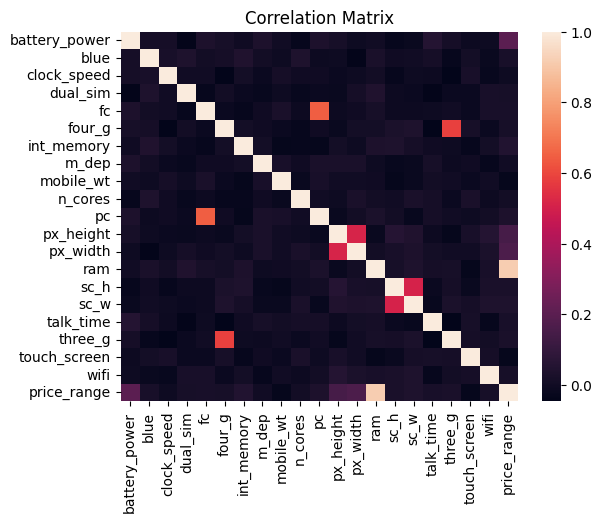

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

## correlation matrix:
matrix = df_train.corr()
print(df_train.columns)

# visualise the correlation matrix
sns.heatmap(matrix)
plt.title('Correlation Matrix')

we see, that the price is mostly related to ram. Other semi high contestants are display dimensions and battery power. Additionally, although we need to predict the price range, we find out, that it is a classification task.

## Model implementation
in the following we implement some popular models. For this task we should expect a random forest or gradient boosting algorithm to perform best. We compare them in the following, while also applying a Grid search cross validation and a K fold cross validation.

In [3]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Users\pstay\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [4]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
import numpy as np

X,y = df_train.drop(columns="price_range"), df_train["price_range"]

skf = StratifiedKFold(n_splits=10, shuffle=True)

Booster = XGBClassifier(n_estimators=100, max_depth=5)
Random_forrest = sklearn.ensemble.RandomForestClassifier(n_estimators=100)

# test before hyperprameter sweep
score_b = np.mean(cross_val_score(Booster, X, y, cv=skf, scoring='accuracy'))
score_r = np.mean(cross_val_score(Random_forrest, X, y, cv=skf, scoring='accuracy'))
print(f"{10*'='}Before Grid Search{10*'='}")
print(f"Score booster: {score_b:.3f}")
print(f"Score random Forrest: {score_r:.3f}")

# Grid search
GridB = GridSearchCV(
    estimator=Booster,
    param_grid={
        'n_estimators': range(100,301,50),
        'max_depth': range(5,21,5)},
    scoring='accuracy',
    n_jobs=-1,
    cv = skf
)
GridR = GridSearchCV(
    estimator=Random_forrest,
    param_grid={
        'n_estimators': range(100,301,50),
        'max_depth': range(5,21,5)},
    scoring='accuracy',
    n_jobs=-1,
    cv = skf
)

print(f"{10*'='}Grid search{10*'='}")
GridB.fit(X,y)
GridR.fit(X,y)
print(f"Score booster: {GridB.score(X, y):.3f} with parameters: {GridB.best_params_}")
print(f"Score Random Forrest: {GridR.score(X, y):.3f} with parameters: {GridR.best_params_}")

print(GridR.cv_results_)


==========Before Grid Search==========
Score booster: 0.922
Score random Forrest: 0.882
==========Grid search==========


Score booster: 1.000 with parameters: {'max_depth': 5, 'n_estimators': 100}
Score Random Forrest: 1.000 with parameters: {'max_depth': 15, 'n_estimators': 300}
{'mean_fit_time': array([0.41937551, 0.60233119, 0.85706716, 1.11916385, 1.23764405,
       0.63791671, 0.89349055, 1.16616645, 1.44403889, 2.36203477,
       0.8712337 , 1.12705054, 1.29313309, 1.55192211, 1.77066889,
       0.59377053, 0.91321213, 1.2793997 , 1.62419281, 1.64080677]), 'std_fit_time': array([0.08479764, 0.07902155, 0.13547398, 0.17591658, 0.15846144,
       0.12742403, 0.11537708, 0.10194927, 0.14267984, 0.55884423,
       0.24989405, 0.1774747 , 0.16693425, 0.11548067, 0.04743814,
       0.02189721, 0.03795501, 0.11172859, 0.16537048, 0.16181734]), 'mean_score_time': array([0.014364  , 0.01908209, 0.02611086, 0.02745063, 0.02838759,
       0.0141701 , 0.01910498, 0.02497451, 0.02874539, 0.04630468,
       0.0264406 , 0.02313521, 0.02691059, 0.02743444, 0.03294766,
       0.01302099, 0.01983085, 0.02273614, 0.0

### Evaluation metrics
`test.csv` has no `price_range` column (it's the Kaggle submission set), so we can't compute a confusion matrix against it. Instead we use `cross_val_predict` to get out-of-fold predictions on the training data for each tuned model, then look at their confusion matrix plus accuracy, precision, recall and F1 (macro-averaged over the 4 price classes).

==========XGBoost==========
Accuracy:  0.919
Precision: 0.919
Recall:    0.919
F1:        0.919
==========Random Forest==========
Accuracy:  0.888
Precision: 0.888
Recall:    0.888
F1:        0.888


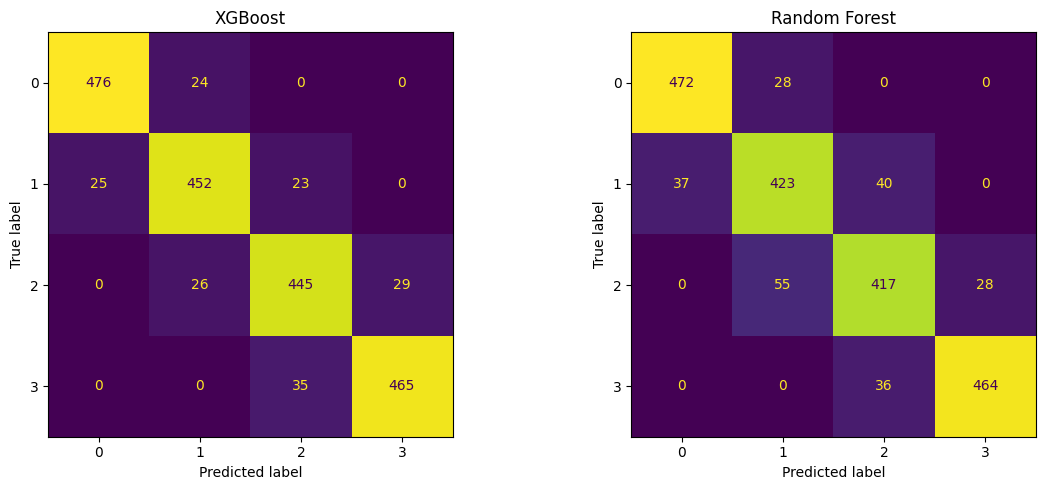

In [5]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
)

y_pred_booster = cross_val_predict(GridB.best_estimator_, X, y, cv=skf)
y_pred_forest = cross_val_predict(GridR.best_estimator_, X, y, cv=skf)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, y_pred, name in zip(axes, [y_pred_booster, y_pred_forest], ["XGBoost", "Random Forest"]):
    print(f"{10*'='}{name}{10*'='}")
    print(f"Accuracy:  {accuracy_score(y, y_pred):.3f}")
    print(f"Precision: {precision_score(y, y_pred, average='macro'):.3f}")
    print(f"Recall:    {recall_score(y, y_pred, average='macro'):.3f}")
    print(f"F1:        {f1_score(y, y_pred, average='macro'):.3f}")
    ConfusionMatrixDisplay(confusion_matrix(y, y_pred)).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

### Prediction
We use the gradient boosting algorithm to predict the test data while practicing some data handling

<Axes: xlabel='pred', ylabel='Count'>

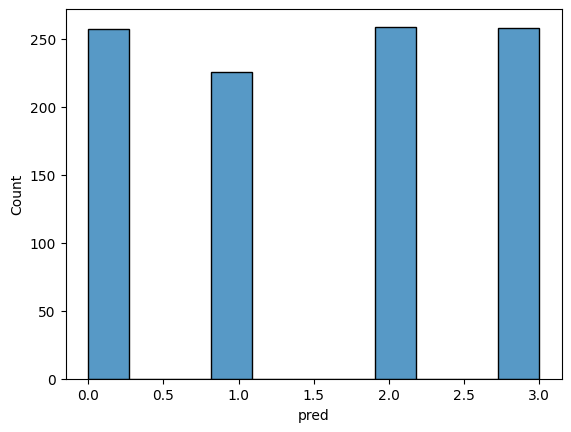

In [6]:
result = GridB.best_estimator_.predict(df_test.drop(columns="id"))
l = pd.DataFrame(result, columns=["pred"])
l.insert(loc = 0, column = "id", value = range(0,1000))

sns.histplot(l["pred"])